In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv'

df = pd.read_csv(file_path)
df.head()


,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [ ]:
target = "Gallstone Status"

X = df.drop(columns=[target])
y = df[target]


In [ ]:
def build_ann(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_dim=input_dim))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
smote = SMOTE()
scaler = StandardScaler()


In [ ]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

history_list = []
y_test_all = []
y_pred_all = []


In [ ]:
fold = 1
for train_idx, test_idx in kfold.split(X, y):

    print(f"\n===== FOLD {fold} =====")

    # Split
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # SMOTE
    X_train, y_train = smote.fit_resample(X_train, y_train)

    # Build ANN
    model = build_ann(X_train.shape[1])

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    history_list.append(history)

    # Predict
    y_pred_prob = model.predict(X_test).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Store for confusion matrix
    y_test_all.extend(y_test)
    y_pred_all.extend(y_pred)

    # Metrics
    acc_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_pred_prob))

    fold += 1



===== FOLD 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

===== FOLD 2 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

===== FOLD 3 =====


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

===== FOLD 9 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

===== FOLD 10 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [ ]:
print("\n===== HASIL RATA-RATA 10-FOLD CV =====")
print("Accuracy :", np.mean(acc_scores))
print("Precision:", np.mean(precision_scores))
print("Recall   :", np.mean(recall_scores))
print("F1 Score :", np.mean(f1_scores))
print("ROC-AUC  :", np.mean(auc_scores))



===== HASIL RATA-RATA 10-FOLD CV =====
Accuracy : 0.7863035430988894
Precision: 0.5790245220895376
Recall   : 0.6720588235294118
F1 Score : 0.6189854310514283
ROC-AUC  : 0.8450626953680022


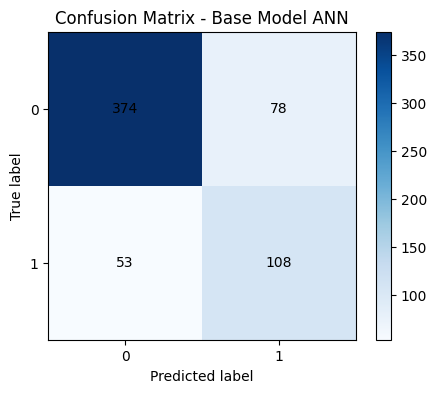

In [ ]:
cm = confusion_matrix(y_test_all, y_pred_all)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Base Model ANN")
plt.colorbar()
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='black')

plt.show()


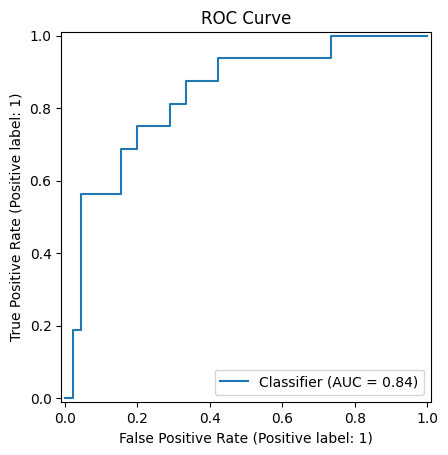

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_pred_prob)
plt.title("ROC Curve")
plt.show()


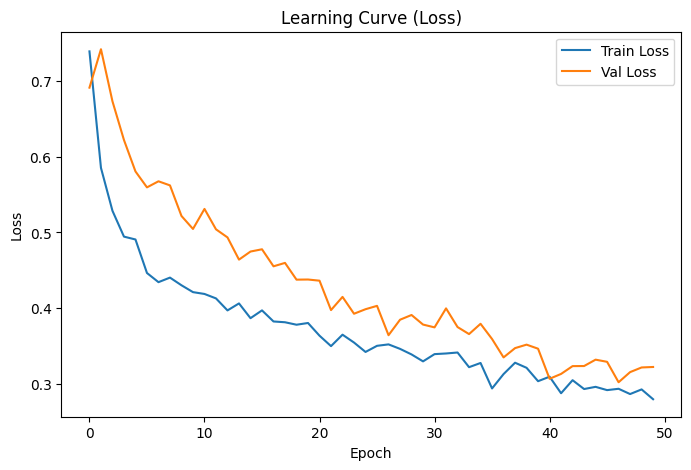

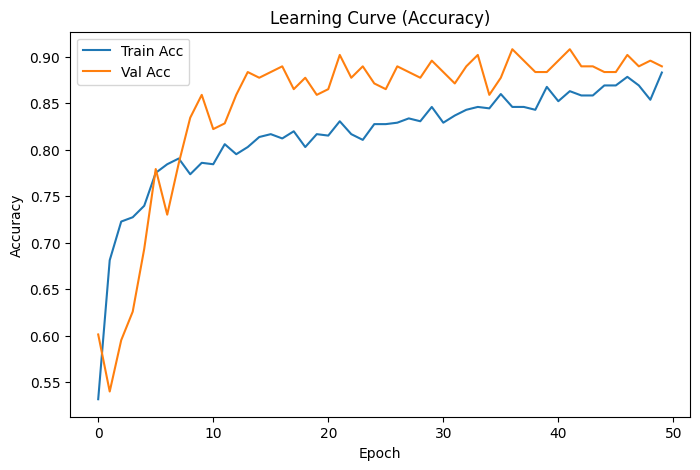

In [ ]:
history_0 = history_list[0]

plt.figure(figsize=(8,5))
plt.plot(history_0.history['loss'], label='Train Loss')
plt.plot(history_0.history['val_loss'], label='Val Loss')
plt.title("Learning Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_0.history['accuracy'], label='Train Acc')
plt.plot(history_0.history['val_accuracy'], label='Val Acc')
plt.title("Learning Curve (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
import os
import json
import joblib
import numpy as np

# ======================================================
# 1. Buat Folder Output Base Model
# ======================================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/"
os.makedirs(output_dir, exist_ok=True)

print("Folder dibuat:", output_dir)

# ======================================================
# 2. Simpan Model ANN Base (gunakan model fold 1)
# ======================================================
base_ann_model_path = os.path.join(output_dir, "base_ann_model_fold1.h5")
history_0.model.save(base_ann_model_path)
print("✔ Saved model:", base_ann_model_path)

# ======================================================
# 3. Simpan Feature Names
# ======================================================
feature_names_path = os.path.join(output_dir, "feature_names.json")
with open(feature_names_path, "w") as f:
    json.dump(list(X.columns), f, indent=4)

print("✔ Saved feature names:", feature_names_path)

# ======================================================
# 4. Simpan Scaler Fold 1 (penting untuk Streamlit)
# ======================================================
# scaler di fold 1 digunakan pertama kali dalam loop
# karena kita deklarasikan scaler ulang setiap fold,
# maka scaler saat fold 1 adalah scaler sebelum oversampling.

scaler_fold1_path = os.path.join(output_dir, "scaler_fold1.pkl")
joblib.dump(scaler, scaler_fold1_path)

print("✔ Saved scaler:", scaler_fold1_path)

# ======================================================
# 5. Simpan Evaluasi CV
# ======================================================
cv_scores = {
    "accuracy_mean": float(np.mean(acc_scores)),
    "precision_mean": float(np.mean(precision_scores)),
    "recall_mean": float(np.mean(recall_scores)),
    "f1_mean": float(np.mean(f1_scores)),
    "roc_auc_mean": float(np.mean(auc_scores)),
}

cv_metrics_path = os.path.join(output_dir, "cv_metrics.json")
with open(cv_metrics_path, "w") as f:
    json.dump(cv_scores, f, indent=4)

print("✔ Saved CV metrics:", cv_metrics_path)

# ======================================================
# 6. Simpan Confusion Matrix (gabungan 5-fold)
# ======================================================
cm_path = os.path.join(output_dir, "confusion_matrix.npy")
np.save(cm_path, cm)

print("✔ Saved confusion matrix:", cm_path)

# ======================================================
# 7. Simpan Data ROC Fold 1
# ======================================================
roc_path = os.path.join(output_dir, "roc_data_fold1.npz")
np.savez(
    roc_path,
    y_true=np.array(y_test),
    y_prob=np.array(y_pred_prob)
)

print("✔ Saved ROC data:", roc_path)

print("\n>>> Semua file Base Model berhasil disimpan! <<<")


Folder dibuat: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/
✔ Saved model: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/base_ann_model_fold1.h5
✔ Saved feature names: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/feature_names.json
✔ Saved scaler: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/scaler_fold1.pkl
✔ Saved CV metrics: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/cv_metrics.json
✔ Saved confusion matrix: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/confusion_matrix.npy
✔ Saved ROC data: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Base Model/roc_data_fold1.npz

>>> Semua file Base Model berhasil disimpan! <<<


**Hyperparameter Tunning**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
class KerasClassifierCustom(BaseEstimator, ClassifierMixin):
    def __init__(self, units1=64, units2=32, dropout1=0.3, dropout2=0.2,
                 lr=0.001, batch_size=32, epochs=50):
        self.units1 = units1
        self.units2 = units2
        self.dropout1 = dropout1
        self.dropout2 = dropout2
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs

    def build_model(self, input_dim):
        model = Sequential()
        model.add(Dense(self.units1, activation='relu', input_dim=input_dim))
        model.add(Dropout(self.dropout1))
        model.add(Dense(self.units2, activation='relu'))
        model.add(Dropout(self.dropout2))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            optimizer=Adam(learning_rate=self.lr),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model

    def fit(self, X, y):
        self.model_ = self.build_model(X.shape[1])
        self.history_ = self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=0
        )
        return self

    def predict(self, X):
        pred_prob = self.model_.predict(X).ravel()
        return (pred_prob > 0.5).astype(int)

    def predict_proba(self, X):
        return np.column_stack([1 - self.model_.predict(X).ravel(),
                                self.model_.predict(X).ravel()])


In [ ]:
file_path = '/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv'

df = pd.read_csv(file_path)
target = "Gallstone Status"

X = df.drop(columns=[target])
y = df[target]


In [ ]:
pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE()),
    ("ann", KerasClassifierCustom())
])


In [ ]:
param_distributions = {
    "ann__units1": [32, 64, 128],
    "ann__units2": [16, 32, 64],
    "ann__dropout1": [0.2, 0.3, 0.4],
    "ann__dropout2": [0.1, 0.2, 0.3],
    "ann__lr": [0.0005, 0.001, 0.005],
    "ann__batch_size": [16, 32, 64],
    "ann__epochs": [30, 50, 70]
}


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=cv,
    scoring="roc_auc",
    verbose=2
)

search.fit(X, y)


Fitting 10 folds for each of 10 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^

[CV] END ann__batch_size=16, ann__dropout1=0.2, ann__dropout2=0.3, ann__epochs=30, ann__lr=0.005, ann__units1=64, ann__units2=32; total time=   6.3s


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

[CV] END ann__batch_size=16, ann__dropout1=0.2, ann__dropout2=0.3, ann__epochs=30, ann__lr=0.005, ann__units1=64, ann__units2=32; total time=   5.2s


...

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

[CV] END ann__batch_size=64, ann__dropout1=0.3, ann__dropout2=0.1, ann__epochs=70, ann__lr=0.001, ann__units1=64, ann__units2=16; total time=   7.2s


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
   

[CV] END ann__batch_size=64, ann__dropout1=0.3, ann__dropout2=0.1, ann__epochs=70, ann__lr=0.001, ann__units1=64, ann__units2=16; total time=   5.9s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE()),
                                             ('ann', KerasClassifierCustom())]),
                   param_distributions={'ann__batch_size': [16, 32, 64],
                                        'ann__dropout1': [0.2, 0.3, 0.4],
                                        'ann__dropout2': [0.1, 0.2, 0.3],
                                        'ann__epochs': [30, 50, 70],
                                        'ann__lr': [0.0005, 0.001, 0.005],
                                        'ann__units1': [32, 64, 128],
                                        'ann__units2': [16, 32, 64]},
                   scoring='roc_auc', verbose=2)

In [ ]:
print("Best Parameters:", search.best_params_)
print("Best Score (ROC-AUC CV):", search.best_score_)


Best Parameters: {'ann__units2': 32, 'ann__units1': 64, 'ann__lr': 0.005, 'ann__epochs': 30, 'ann__dropout2': 0.3, 'ann__dropout1': 0.2, 'ann__batch_size': 16}
Best Score (ROC-AUC CV): nan


In [ ]:
best_model = search.best_estimator_

y_pred = best_model.predict(X)
y_pred_prob = best_model.predict_proba(X)[:,1]

print("\n=== Evaluation Metrics ===")
print("Accuracy :", accuracy_score(y, y_pred))
print("Precision:", precision_score(y, y_pred))
print("Recall   :", recall_score(y, y_pred))
print("F1 Score :", f1_score(y, y_pred))
print("ROC-AUC  :", roc_auc_score(y, y_pred_prob))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

=== Evaluation Metrics ===
Accuracy : 0.9461663947797716
Precision: 0.8333333333333334
Recall   : 0.9937888198757764
F1 Score : 0.9065155807365439
ROC-AUC  : 0.9901335678557687


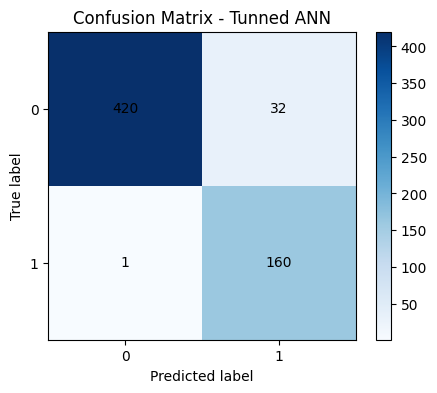

In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Tunned ANN")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


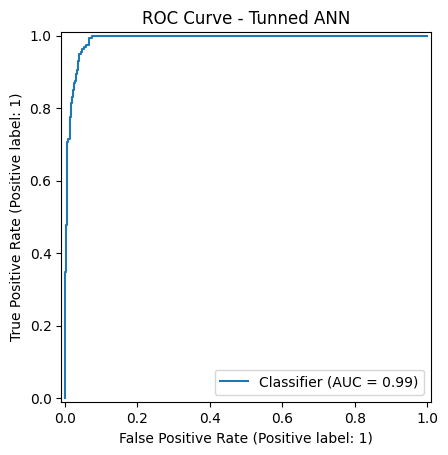

In [ ]:
RocCurveDisplay.from_predictions(y, y_pred_prob)
plt.title("ROC Curve - Tunned ANN")
plt.show()


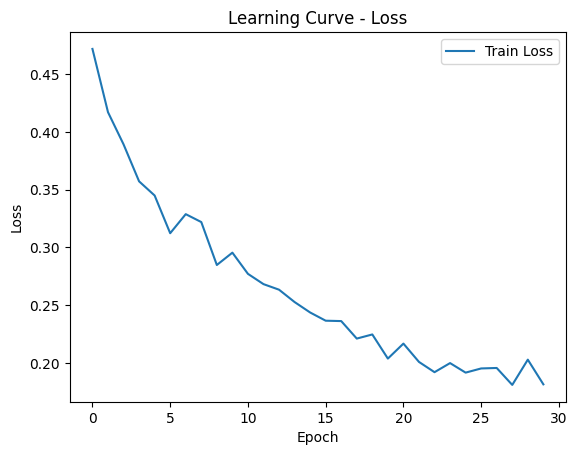

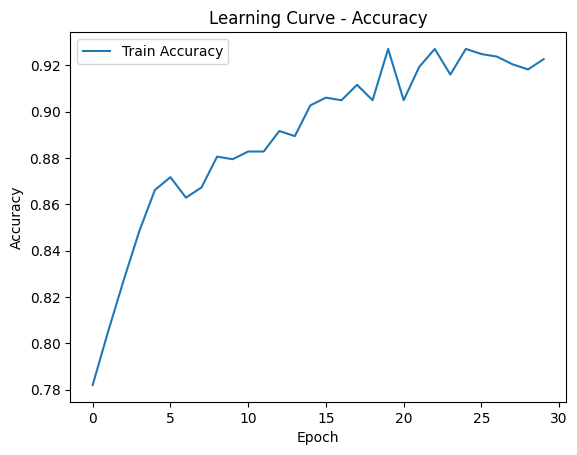

In [ ]:
history = best_model.named_steps["ann"].history_

plt.plot(history.history["loss"], label="Train Loss")
plt.title("Learning Curve - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.title("Learning Curve - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
import os
import json
import joblib
import numpy as np

# ================================
# 1. Buat Folder Output
# ================================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)

# ================================
# 2. Simpan Pipeline Full (scaler, SMOTE, ANN tuned)
#    -> Untuk nanti langsung load di Streamlit
# ================================
best_pipeline_path = os.path.join(output_dir, "best_ann_pipeline.pkl")
joblib.dump(best_model, best_pipeline_path)
print("✔ Saved:", best_pipeline_path)

# ================================
# 3. Simpan Parameter Terbaik
# ================================
best_params_path = os.path.join(output_dir, "best_params.json")
with open(best_params_path, "w") as f:
    json.dump(search.best_params_, f, indent=4)

print("✔ Saved:", best_params_path)

# ================================
# 4. Simpan Model ANN Saja (tanpa scaler/SMOTE)
#    -> Berguna kalau mau dipakai ulang
# ================================
ann_model = best_model.named_steps["ann"].model_

ann_h5_path = os.path.join(output_dir, "best_ann_model.h5")
ann_model.save(ann_h5_path)
print("✔ Saved:", ann_h5_path)

# ================================
# 5. Simpan Feature Names (untuk Streamlit)
# ================================
feature_names_path = os.path.join(output_dir, "feature_names.json")
with open(feature_names_path, "w") as f:
    json.dump(list(X.columns), f, indent=4)

print("✔ Saved:", feature_names_path)

# ================================
# 6. Simpan Learning Curve (Loss & Accuracy) ke file .npz
# ================================
history = best_model.named_steps["ann"].history_

learning_curve_path = os.path.join(output_dir, "learning_curve_history.npz")
np.savez(
    learning_curve_path,
    loss=np.array(history.history["loss"]),
    accuracy=np.array(history.history["accuracy"])
)

print("✔ Saved:", learning_curve_path)

# ================================
# 7. Simpan Confusion Matrix & ROC Data untuk Streamlit
# ================================
cm_output_path = os.path.join(output_dir, "eval_confusion_matrix.npy")
roc_output_path = os.path.join(output_dir, "eval_roc_data.npz")

np.save(cm_output_path, cm)

np.savez(
    roc_output_path,
    y_true=np.array(y),
    y_prob=np.array(y_pred_prob)
)

print("✔ Saved:", cm_output_path)
print("✔ Saved:", roc_output_path)


✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/best_ann_pipeline.pkl


✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/best_params.json
✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/best_ann_model.h5
✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/feature_names.json
✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/learning_curve_history.npz
✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/eval_confusion_matrix.npy
✔ Saved: /content/drive/MyDrive/Tesis/Fix FE CV/ANN/Tuned Model/eval_roc_data.npz


Steamlite

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import joblib
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset (sama persis dengan training)
df = pd.read_csv(
    "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
)

target = "Gallstone Status"
X = df.drop(columns=[target])

# Pastikan kolom sama
X = X[X.columns]

# Fit scaler ulang (INI BOLEH, tidak pakai label)
scaler = StandardScaler()
scaler.fit(X)

# Simpan scaler saja
joblib.dump(
    scaler,
    "/content/drive/MyDrive/Tesis/gallstone-streamlit/scaler.pkl"
)

print("✔ scaler.pkl berhasil disimpan")


✔ scaler.pkl berhasil disimpan


In [4]:
import json

feature_names = list(X.columns)

with open(
    "/content/drive/MyDrive/Tesis/gallstone-streamlit/feature_names.json",
    "w"
) as f:
    json.dump(feature_names, f, indent=4)

print("✔ feature_names.json berhasil disimpan")


✔ feature_names.json berhasil disimpan


In [5]:
import pandas as pd
import joblib
from sklearn.impute import KNNImputer

# ================================
# LOAD DATASET TRAINING
# ================================
DATA_PATH = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"

df = pd.read_csv(DATA_PATH)

target = "Gallstone Status"
X = df.drop(columns=[target])

print("Jumlah fitur:", X.shape[1])
X.head()


Jumlah fitur: 30


,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [6]:
# ================================
# FIT KNN IMPUTER
# ================================
knn_imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

knn_imputer.fit(X)

print("KNN Imputer berhasil di-fit")


KNN Imputer berhasil di-fit


In [7]:
# ================================
# SAVE IMPUTER
# ================================
output_path = "/content/drive/MyDrive/Tesis/gallstone-streamlit/knn_imputer.pkl"

joblib.dump(knn_imputer, output_path)

print("✔ knn_imputer.pkl disimpan di:", output_path)


✔ knn_imputer.pkl disimpan di: /content/drive/MyDrive/Tesis/gallstone-streamlit/knn_imputer.pkl
